# MindCare — Optimized CPU Training Pipeline
**Semantic & Temporal Analysis of Social Media Text for Student Mental Health Assessment**

FAST-NUCES FYP | Muhammad Tauseef Ahmad · Ahyan Ali Khan · Hamza Khurram

---
### CPU Optimizations Applied:
- **Dataset sampling**: trains on a configurable subset (default 20k rows) — reduces time by 5–10×
- **SBERT batch size**: tuned for CPU memory (64 → 128 with thread pinning)
- **Embedding cache**: computed once, reloaded on re-run — zero recomputation cost
- **Thread pinning**: `torch.set_num_threads` set to physical core count
- **Time estimator**: shows ETA before each model trains
- **Reduced epochs**: sensible defaults for CPU (tunable)
- **Bug fixes**: indentation in `SBERTBiLSTMEnsemble.forward`, missing `df_train/val/test` splits, duplicate SBERT encode, wrong `SBERT_MODEL_NAME` in metadata

## 0. Install Dependencies

In [1]:
# Run once
%pip install --upgrade pip -q
%pip install sentence-transformers transformers torch scikit-learn shap lime flask flask-cors pandas numpy matplotlib seaborn joblib tqdm -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 1. Imports & Configuration

In [2]:
import os, re, json, warnings, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# ─── Scikit-learn ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV

# ─── Sentence Transformers ───────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer

# ─── PyTorch ─────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# ─── Explainability ──────────────────────────────────────────────────────────
import shap
import lime
import lime.lime_text

# ─── Serialization ───────────────────────────────────────────────────────────
import joblib

# ─── Seeds for reproducibility ───────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─── CPU Optimization: set threads to physical core count ───────────────────
import multiprocessing
NUM_PHYSICAL_CORES = multiprocessing.cpu_count()
torch.set_num_threads(NUM_PHYSICAL_CORES)
print(f'Physical CPU cores detected: {NUM_PHYSICAL_CORES}')
print(f'PyTorch threads set to: {NUM_PHYSICAL_CORES}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ─── Directory for saving artefacts ──────────────────────────────────────────
SAVE_DIR = 'models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ─── MASTER SAMPLING CONFIG (change this to control speed vs. accuracy) ──────
# Set to None to use the full dataset.
# 20000 rows ≈ 30–45 min total on a 2-core CPU without GPU.
SAMPLE_SIZE = 20000

print(f'\nSAMPLE_SIZE = {SAMPLE_SIZE} (set to None for full dataset)')
print('MindCare optimized pipeline initialised.')

C:\Users\tause\AppData\Local\Temp\ipykernel_14732\715511567.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
f:\MindCareFYP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

## 2. Data Loading & Preprocessing

In [ ]:
# ─── UPDATE THIS PATH ────────────────────────────────────────────────────────
DATA_PATH = r"C:\Users\tause\Downloads\processed_data.csv"   # <-- change if needed

df_full = pd.read_csv(DATA_PATH)
print(f'Full dataset shape: {df_full.shape}')
print('Columns:', df_full.columns.tolist())

Full dataset shape: (1107302, 4)
Columns: ['label', 'text', 'clean_text', 'tokens']


In [ ]:
# ─── MindCare Level Mapping ───────────────────────────────────────────────────
MINDCARE_LEVEL_MAP = {
    'normal': 0, 'wellness': 0, 'fitness': 0, 'meditation': 0, 'jokes': 0,
    'stress': 1, 'mild stress': 1, 'relationships': 1, 'life stress': 1,
    'adhd': 2, 'autism': 2, 'behavioral': 2,
    'anxiety': 3, 'health anxiety': 3, 'social anxiety': 3,
    'depression': 4, 'depressed': 4, 'bipolar': 4, 'ptsd': 4,
    'bpd': 5, 'lonely': 5, 'personality disorder': 5,
    'schizophrenia': 6, 'addiction': 6, 'alcoholism': 6,
    'suicidal': 7, 'suicide': 7, 'suicidewatch': 7,
}
MINDCARE_LEVEL_MAP = {k.lower(): v for k, v in MINDCARE_LEVEL_MAP.items()}

LEVEL_NAMES = {
    0: 'Normal',
    1: 'Mild Stress',
    2: 'Moderate Behavioral',
    3: 'Anxiety',
    4: 'Depression / Mood Disorder',
    5: 'Personality / Social Distress',
    6: 'Severe Clinical',
    7: 'Crisis / Suicidal Risk',
}

INTERVENTION_MAP = {
    0: 'Maintain healthy lifestyle.',
    1: 'Practice stress management.',
    2: 'Use coping strategies and support.',
    3: 'Counselling recommended.',
    4: 'Clinical therapy advised.',
    5: 'Structured therapy (CBT/DBT).',
    6: 'Medical intervention required.',
    7: 'Immediate crisis support required.',
}

print(f'Mapping ready for {len(MINDCARE_LEVEL_MAP)} labels.')

Mapping ready for 28 labels.


In [ ]:
# ─── Text column ─────────────────────────────────────────────────────────────
df_full['text'] = df_full['clean_text'].fillna('').astype(str)
df_full = df_full[df_full['text'].str.len() > 10].copy()

# ─── Label normalization ─────────────────────────────────────────────────────
df_full['label'] = df_full['label'].astype(str).str.lower().str.strip()
label_fix = {'depressed': 'depression', 'sad': 'depression', 'panic': 'anxiety', 'suicide': 'suicidal'}
df_full['label'] = df_full['label'].replace(label_fix)

df_full['mindcare_level'] = df_full['label'].map(lambda x: MINDCARE_LEVEL_MAP.get(x, -1))

unknown_labels = df_full[df_full['mindcare_level'] == -1]['label'].unique()
print('Unmapped labels:', unknown_labels)

df_full = df_full[df_full['mindcare_level'] != -1].copy()
df_full['mindcare_level'] = df_full['mindcare_level'].astype(int)

print(f'Clean full dataset: {df_full.shape}')
print(df_full['mindcare_level'].value_counts().sort_index())

Unmapped labels: <StringArray>
[  'bipolarreddit',        'teaching',   'healthanxiety',            'guns',
 'covid19_support', 'personalfinance',     'legaladvice',         'divorce',
      'conspiracy',       'parenting',   'socialanxiety',    'mentalhealth',
     'edanonymous']
Length: 13, dtype: str
Clean full dataset: (612509, 5)
mindcare_level
0    160815
1     77223
2     54499
3     57670
4    125966
5     47928
6     22264
7     66144
Name: count, dtype: int64


In [ ]:
# ─── STRATIFIED SAMPLING (key CPU optimization) ───────────────────────────────
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df_full):
    df, _ = train_test_split(
        df_full,
        train_size=SAMPLE_SIZE,
        random_state=SEED,
        stratify=df_full['mindcare_level']
    )
    print(f'Using stratified sample: {len(df)} / {len(df_full)} rows')
else:
    df = df_full.copy()
    print(f'Using full dataset: {len(df)} rows')

NUM_CLASSES = df['mindcare_level'].nunique()
CLASS_NAMES = [LEVEL_NAMES.get(i, str(i)) for i in sorted(df['mindcare_level'].unique())]
print(f'Classes ({NUM_CLASSES}):', CLASS_NAMES)

Using stratified sample: 20000 / 612509 rows
Classes (8): ['Normal', 'Mild Stress', 'Moderate Behavioral', 'Anxiety', 'Depression / Mood Disorder', 'Personality / Social Distress', 'Severe Clinical', 'Crisis / Suicidal Risk']


In [ ]:
# ─── Train / Val / Test Split ─────────────────────────────────────────────────
X = df['text'].values
y = df['mindcare_level'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=SEED, stratify=y_temp
)

# Build df splits for token-based models
df_train = df.iloc[:len(X_train)].copy()  # approximate — only used for vocab building

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

def show_dist(name, y_arr):
    unique, counts = np.unique(y_arr, return_counts=True)
    dist = {LEVEL_NAMES.get(int(k), k): int(v) for k, v in zip(unique, counts)}
    print(f"{name} distribution:", dist)

show_dist('Train', y_train)
show_dist('Val', y_val)
show_dist('Test', y_test)

# ─── Class weights ────────────────────────────────────────────────────────────
classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
CLASS_WEIGHTS = torch.ones(len(LEVEL_NAMES))
for c, w in class_weight_dict.items():
    CLASS_WEIGHTS[c] = w
CLASS_WEIGHTS = CLASS_WEIGHTS.to(DEVICE)
print('Class weights ready.')

Train: 14450 | Val: 2550 | Test: 3000
Train distribution: {'Normal': 3794, 'Mild Stress': 1821, 'Moderate Behavioral': 1286, 'Anxiety': 1361, 'Depression / Mood Disorder': 2972, 'Personality / Social Distress': 1130, 'Severe Clinical': 525, 'Crisis / Suicidal Risk': 1561}
Val distribution: {'Normal': 669, 'Mild Stress': 322, 'Moderate Behavioral': 227, 'Anxiety': 240, 'Depression / Mood Disorder': 524, 'Personality / Social Distress': 200, 'Severe Clinical': 93, 'Crisis / Suicidal Risk': 275}
Test distribution: {'Normal': 788, 'Mild Stress': 378, 'Moderate Behavioral': 267, 'Anxiety': 282, 'Depression / Mood Disorder': 617, 'Personality / Social Distress': 235, 'Severe Clinical': 109, 'Crisis / Suicidal Risk': 324}
Class weights ready.


## 2b. Time Estimator Utility

In [ ]:
def estimate_training_time(model, sample_dl, epochs, use_embs=False):
    """
    Runs 2 warm-up batches to estimate total training time before full training.
    Prints ETA and returns seconds-per-epoch.
    """
    model.train()
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    optimiser = AdamW(model.parameters(), lr=1e-3)

    batch_times = []
    for i, batch in enumerate(sample_dl):
        if i >= 3:
            break
        t0 = time.perf_counter()
        ids    = batch['ids'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)
        embs   = batch['embs'].to(DEVICE) if use_embs and 'embs' in batch else None
        optimiser.zero_grad()
        logits = model(ids, embs) if use_embs else model(ids)
        loss   = criterion(logits, labels)
        loss.backward()
        optimiser.step()
        batch_times.append(time.perf_counter() - t0)

    avg_batch_sec = np.mean(batch_times)
    total_batches = len(sample_dl)
    sec_per_epoch = avg_batch_sec * total_batches
    total_sec     = sec_per_epoch * epochs

    print(f'  Avg batch time : {avg_batch_sec*1000:.1f} ms')
    print(f'  Batches/epoch  : {total_batches}')
    print(f'  Est. per epoch : {sec_per_epoch/60:.1f} min')
    print(f'  Est. total     : {total_sec/60:.1f} min  ({epochs} epochs)')
    return sec_per_epoch

print('Time estimator ready.')

Time estimator ready.


## 3. Model 1 — SBERT + Logistic Regression (Baseline)

In [ ]:
# ─── SBERT Encoding with Caching ─────────────────────────────────────────────
SBERT_MODEL_NAME = 'all-MiniLM-L6-v2'
SBERT_BATCH_SIZE = 128   # CPU sweet-spot; reduce to 64 if RAM is tight

SBERT = SentenceTransformer(
    SBERT_MODEL_NAME,
    device='cpu',
    cache_folder='./hf_cache'
)

print(f'SBERT loaded: {SBERT_MODEL_NAME}')


def encode_fast(texts, cache_file, batch_size=SBERT_BATCH_SIZE):
    """Encode with SBERT; skip recomputation if cache exists."""
    if os.path.exists(cache_file):
        print(f'  Loading cached embeddings: {cache_file}')
        return np.load(cache_file)
    print(f'  Encoding {len(texts)} texts → {cache_file}')
    t0 = time.perf_counter()
    embs = SBERT.encode(
        list(texts),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    elapsed = time.perf_counter() - t0
    print(f'  Done in {elapsed/60:.1f} min  → shape {embs.shape}')
    np.save(cache_file, embs)
    return embs


# Estimate SBERT encode time before running
print('\nEstimating SBERT encoding time...')
probe = list(X_train[:50])
t0 = time.perf_counter()
SBERT.encode(probe, batch_size=SBERT_BATCH_SIZE, show_progress_bar=False)
probe_sec = time.perf_counter() - t0
rate = 50 / probe_sec  # texts/sec
total_texts = len(X_train) + len(X_val) + len(X_test)
eta_min = total_texts / rate / 60
print(f'  Rate: {rate:.0f} texts/sec')
print(f'  ETA to encode all splits: ~{eta_min:.1f} min')


# ─── Encode (cached) ─────────────────────────────────────────────────────────
train_emb = encode_fast(X_train, 'train_emb.npy')
val_emb   = encode_fast(X_val,   'val_emb.npy')
test_emb  = encode_fast(X_test,  'test_emb.npy')

print(f'\nEmbedding shapes — Train: {train_emb.shape}  Val: {val_emb.shape}  Test: {test_emb.shape}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2654.26it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SBERT loaded: all-MiniLM-L6-v2

Estimating SBERT encoding time...
  Rate: 8 texts/sec
  ETA to encode all splits: ~42.2 min
  Encoding 14450 texts → train_emb.npy


Batches: 100%|██████████| 113/113 [12:46<00:00,  6.79s/it]


  Done in 12.8 min  → shape (14450, 384)
  Encoding 2550 texts → val_emb.npy


Batches: 100%|██████████| 20/20 [01:39<00:00,  4.96s/it]


  Done in 1.7 min  → shape (2550, 384)
  Encoding 3000 texts → test_emb.npy


Batches: 100%|██████████| 24/24 [01:56<00:00,  4.86s/it]

  Done in 2.0 min  → shape (3000, 384)

Embedding shapes — Train: (14450, 384)  Val: (2550, 384)  Test: (3000, 384)


In [ ]:
# ─── Logistic Regression ─────────────────────────────────────────────────────
print('Training SBERT + Logistic Regression...')
t0 = time.perf_counter()

base_lr = LogisticRegression(
    max_iter=2000,
    C=2.0,
    solver='lbfgs',
    #multi_class='auto',
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED
)

lr_model = CalibratedClassifierCV(base_lr, method='sigmoid', cv=3)
lr_model.fit(train_emb, y_train)

print(f'Training done in {(time.perf_counter()-t0)/60:.1f} min')

lr_preds = lr_model.predict(test_emb)
lr_acc   = accuracy_score(y_test, lr_preds)
lr_f1    = f1_score(y_test, lr_preds, average='weighted')

print(f'\n=== Model 1: SBERT + Logistic Regression ===')
print(f'Test Accuracy : {lr_acc:.4f}')
print(f'Weighted F1   : {lr_f1:.4f}')
print(classification_report(y_test, lr_preds,
      target_names=[LEVEL_NAMES.get(i, str(i)) for i in sorted(set(y_test))]))

joblib.dump(lr_model, f'{SAVE_DIR}/sbert_lr_model.pkl')
with open(f'{SAVE_DIR}/sbert_config.json', 'w') as f:
    json.dump({'model_name': SBERT_MODEL_NAME}, f)
print('Model 1 saved.')

Training SBERT + Logistic Regression...
Training done in 0.2 min

=== Model 1: SBERT + Logistic Regression ===
Test Accuracy : 0.7613
Weighted F1   : 0.7553
                               precision    recall  f1-score   support

                       Normal       0.89      0.96      0.92       788
                  Mild Stress       0.85      0.90      0.88       378
          Moderate Behavioral       0.85      0.80      0.82       267
                      Anxiety       0.79      0.73      0.76       282
   Depression / Mood Disorder       0.60      0.71      0.65       617
Personality / Social Distress       0.58      0.46      0.51       235
              Severe Clinical       0.68      0.70      0.69       109
       Crisis / Suicidal Risk       0.68      0.44      0.54       324

                     accuracy                           0.76      3000
                    macro avg       0.74      0.71      0.72      3000
                 weighted avg       0.76      0.76      0.76

## 4. Model 2 — LSTM with Custom Tokenizer

In [ ]:
# ─── Vocabulary ──────────────────────────────────────────────────────────────
MAX_VOCAB = 20000
MAX_LEN   = 128
MIN_FREQ  = 2

word_counts = Counter()
for text in X_train:
    tokens = text.split()
    word_counts.update(tokens)
    word_counts.update([tokens[i] + '_' + tokens[i+1] for i in range(len(tokens)-1)])

vocab_words = sorted(
    [w for w, c in word_counts.items() if c >= MIN_FREQ],
    key=lambda w: -word_counts[w]
)[:MAX_VOCAB - 2]

vocab    = ['<PAD>', '<OOV>'] + vocab_words
word2idx = {w: i for i, w in enumerate(vocab)}

print(f'Vocabulary size: {len(vocab)}')


# ─── Encoding function ────────────────────────────────────────────────────────
def encode_text(texts, word2idx, max_len):
    encoded = []
    for t in texts:
        tokens = t.split() if isinstance(t, str) else list(t)
        seq  = tokens[:]
        seq += [tokens[i] + '_' + tokens[i+1] for i in range(len(tokens)-1)]
        ids  = [word2idx.get(w, 1) for w in seq[:max_len]]
        ids += [0] * (max_len - len(ids))
        encoded.append(ids)
    return np.array(encoded, dtype=np.int64)


X_train_ids = encode_text(X_train, word2idx, MAX_LEN)
X_val_ids   = encode_text(X_val,   word2idx, MAX_LEN)
X_test_ids  = encode_text(X_test,  word2idx, MAX_LEN)

with open(f'{SAVE_DIR}/vocab.json', 'w') as f:
    json.dump(word2idx, f)

print(f'Encoding done. Max seq length: {MAX_LEN}')

Vocabulary size: 20000
Encoding done. Max seq length: 128


In [ ]:
# ─── PyTorch Dataset & DataLoaders ───────────────────────────────────────────
class TextDataset(Dataset):
    def __init__(self, ids, labels, embs=None):
        self.ids    = torch.tensor(ids,    dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.embs   = torch.tensor(embs, dtype=torch.float32) if embs is not None else None

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        item = {'ids': self.ids[idx], 'labels': self.labels[idx]}
        if self.embs is not None:
            item['embs'] = self.embs[idx]
        return item


# CPU-optimised DataLoader settings
TRAIN_BATCH = 128   # larger = fewer Python iterations = faster on CPU
INFER_BATCH = 256
NUM_WORKERS = 0     # 0 is fastest on Windows; try 2 on Linux

train_ds = TextDataset(X_train_ids, y_train)
val_ds   = TextDataset(X_val_ids,   y_val)
test_ds  = TextDataset(X_test_ids,  y_test)

train_dl = DataLoader(train_ds, batch_size=TRAIN_BATCH, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=False)
val_dl   = DataLoader(val_ds,   batch_size=INFER_BATCH, shuffle=False, num_workers=NUM_WORKERS)
test_dl  = DataLoader(test_ds,  batch_size=INFER_BATCH, shuffle=False, num_workers=NUM_WORKERS)

print(f'DataLoaders ready — batch size {TRAIN_BATCH} train / {INFER_BATCH} eval')

DataLoaders ready — batch size 128 train / 256 eval


In [ ]:
# ─── LSTM Model ───────────────────────────────────────────────────────────────
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.5):
        super().__init__()
        self.embed  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm   = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=False)
        self.drop   = nn.Dropout(dropout)
        self.fc1    = nn.Linear(hidden_dim, 64)
        self.fc2    = nn.Linear(64, num_classes)

    def forward(self, ids, embs=None):
        emb = self.embed(ids)
        _, (h_n, _) = self.lstm(emb)
        h = h_n[-1]
        h = self.drop(h)
        h = F.relu(self.fc1(h))
        return self.fc2(h)


lstm_model = LSTMClassifier(
    vocab_size=len(vocab), embed_dim=128, hidden_dim=256, num_classes=NUM_CLASSES
).to(DEVICE)

print(f'LSTM parameters: {sum(p.numel() for p in lstm_model.parameters()):,}')

LSTM parameters: 2,972,232


In [ ]:
# ─── Shared Training & Evaluation Utilities ───────────────────────────────────
def train_model(model, train_dl, val_dl, epochs=10, lr=1e-3,
                use_embs=False, model_name='model'):
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    optimiser = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimiser, T_max=epochs)

    best_val_acc, best_state = 0.0, None
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    epoch_times = []
    for epoch in range(1, epochs + 1):
        t0 = time.perf_counter()

        # ── Train ──
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for batch in train_dl:
            ids    = batch['ids'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            embs   = batch['embs'].to(DEVICE) if use_embs and 'embs' in batch else None
            optimiser.zero_grad()
            logits = model(ids, embs) if use_embs else model(ids)
            loss   = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            t_loss    += loss.item() * labels.size(0)
            t_correct += (logits.argmax(1) == labels).sum().item()
            t_total   += labels.size(0)

        # ── Validate ──
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_dl:
                ids    = batch['ids'].to(DEVICE)
                labels = batch['labels'].to(DEVICE)
                embs   = batch['embs'].to(DEVICE) if use_embs and 'embs' in batch else None
                logits = model(ids, embs) if use_embs else model(ids)
                v_loss    += criterion(logits, labels).item() * labels.size(0)
                v_correct += (logits.argmax(1) == labels).sum().item()
                v_total   += labels.size(0)

        train_acc = t_correct / t_total
        val_acc   = v_correct / v_total
        history['train_loss'].append(t_loss / t_total)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(v_loss / v_total)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(best_state, f'{SAVE_DIR}/{model_name}_best.pt')

        scheduler.step()

        epoch_sec = time.perf_counter() - t0
        epoch_times.append(epoch_sec)
        remaining = np.mean(epoch_times) * (epochs - epoch)
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'Train {train_acc:.4f} | Val {val_acc:.4f} | '
              f'Best {best_val_acc:.4f} | '
              f'{epoch_sec:.0f}s/ep | ETA {remaining/60:.1f} min')

    model.load_state_dict(best_state)
    return model, history


def evaluate_model(model, test_dl, use_embs=False):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in test_dl:
            ids    = batch['ids'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            embs   = batch['embs'].to(DEVICE) if use_embs and 'embs' in batch else None
            logits = model(ids, embs) if use_embs else model(ids)
            probs  = F.softmax(logits, dim=-1)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


print('Training utilities ready.')

Training utilities ready.


In [ ]:
# ─── Estimate LSTM training time before committing ────────────────────────────
LSTM_EPOCHS = 10   # reduce to 5–7 on very slow machines

print(f'=== Estimating LSTM training time ({LSTM_EPOCHS} epochs) ===')
estimate_training_time(lstm_model, train_dl, epochs=LSTM_EPOCHS, use_embs=False)

print('\nProceed? (interrupt kernel to cancel, or just run the next cell)')

=== Estimating LSTM training time (10 epochs) ===
  Avg batch time : 894.4 ms
  Batches/epoch  : 113
  Est. per epoch : 1.7 min
  Est. total     : 16.8 min  (10 epochs)

Proceed? (interrupt kernel to cancel, or just run the next cell)


In [ ]:
# Re-init after estimation (estimation modifies weights via warm-up steps)
lstm_model = LSTMClassifier(
    vocab_size=len(vocab), embed_dim=128, hidden_dim=256, num_classes=NUM_CLASSES
).to(DEVICE)

lstm_model, lstm_history = train_model(
    lstm_model, train_dl, val_dl,
    epochs=LSTM_EPOCHS, lr=1e-3, use_embs=False, model_name='lstm'
)

lstm_preds, lstm_labels, lstm_probs = evaluate_model(lstm_model, test_dl)
lstm_acc = accuracy_score(lstm_labels, lstm_preds)
lstm_f1  = f1_score(lstm_labels, lstm_preds, average='weighted')

print(f'\n=== Model 2: LSTM ===')
print(f'Test Accuracy : {lstm_acc:.4f}')
print(f'Weighted F1   : {lstm_f1:.4f}')
print(classification_report(lstm_labels, lstm_preds, target_names=CLASS_NAMES))

Epoch 01/10 | Train 0.2313 | Val 0.3027 | Best 0.3027 | 79s/ep | ETA 11.9 min
Epoch 02/10 | Train 0.3188 | Val 0.3588 | Best 0.3588 | 112s/ep | ETA 12.7 min
Epoch 03/10 | Train 0.3426 | Val 0.3478 | Best 0.3588 | 96s/ep | ETA 11.2 min
Epoch 04/10 | Train 0.3599 | Val 0.3341 | Best 0.3588 | 82s/ep | ETA 9.2 min
Epoch 05/10 | Train 0.3889 | Val 0.3537 | Best 0.3588 | 90s/ep | ETA 7.7 min
Epoch 06/10 | Train 0.4237 | Val 0.3518 | Best 0.3588 | 80s/ep | ETA 6.0 min
Epoch 07/10 | Train 0.4566 | Val 0.4051 | Best 0.4051 | 89s/ep | ETA 4.5 min
Epoch 08/10 | Train 0.4944 | Val 0.4110 | Best 0.4110 | 76s/ep | ETA 2.9 min
Epoch 09/10 | Train 0.4988 | Val 0.4118 | Best 0.4118 | 74s/ep | ETA 1.4 min
Epoch 10/10 | Train 0.5104 | Val 0.4212 | Best 0.4212 | 78s/ep | ETA 0.0 min

=== Model 2: LSTM ===
Test Accuracy : 0.4453
Weighted F1   : 0.4388
                               precision    recall  f1-score   support

                       Normal       0.82      0.72      0.76       788
              

## 5. Model 3 — BiLSTM + Attention

In [ ]:
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, seq, mask=None):
        scores = self.attn(seq).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=-1)
        context = (weights.unsqueeze(-1) * seq).sum(dim=1)
        return context, weights


class BiLSTMAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.4):
        super().__init__()
        self.embed     = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bilstm    = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                                  batch_first=True, bidirectional=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.attention = AttentionLayer(hidden_dim * 2)
        self.layer_norm= nn.LayerNorm(hidden_dim * 2)
        self.drop      = nn.Dropout(dropout)
        self.fc1       = nn.Linear(hidden_dim * 2, 256)
        self.fc2       = nn.Linear(256, 128)
        self.fc3       = nn.Linear(128, num_classes)

    def forward(self, ids, embs=None):
        mask = (ids != 0)
        emb  = self.drop(self.embed(ids))
        seq, _ = self.bilstm(emb)
        ctx, _ = self.attention(seq, mask)
        ctx    = self.layer_norm(ctx)
        ctx    = self.drop(ctx)
        h = F.gelu(self.fc1(ctx))
        h = self.drop(h)
        h = F.gelu(self.fc2(h))
        return self.fc3(h)


bilstm_model = BiLSTMAttention(
    vocab_size=len(vocab), embed_dim=128, hidden_dim=256, num_classes=NUM_CLASSES
).to(DEVICE)

print(f'BiLSTM parameters: {sum(p.numel() for p in bilstm_model.parameters()):,}')

BiLSTM parameters: 5,094,280


In [ ]:
BILSTM_EPOCHS = 9

print(f'=== Estimating BiLSTM training time ({BILSTM_EPOCHS} epochs) ===')
estimate_training_time(bilstm_model, train_dl, epochs=BILSTM_EPOCHS)

# Re-init after estimation
bilstm_model = BiLSTMAttention(
    vocab_size=len(vocab), embed_dim=128, hidden_dim=256, num_classes=NUM_CLASSES
).to(DEVICE)

bilstm_model, bilstm_history = train_model(
    bilstm_model, train_dl, val_dl,
    epochs=BILSTM_EPOCHS, lr=3e-4, use_embs=False, model_name='bilstm_attention'
)

bilstm_preds, bilstm_labels, bilstm_probs = evaluate_model(bilstm_model, test_dl)
bilstm_acc = accuracy_score(bilstm_labels, bilstm_preds)
bilstm_f1  = f1_score(bilstm_labels, bilstm_preds, average='weighted')

print(f'\n=== Model 3: BiLSTM + Attention ===')
print(f'Test Accuracy : {bilstm_acc:.4f}')
print(f'Weighted F1   : {bilstm_f1:.4f}')
print(classification_report(bilstm_labels, bilstm_preds, target_names=CLASS_NAMES))

=== Estimating BiLSTM training time (9 epochs) ===
  Avg batch time : 4538.9 ms
  Batches/epoch  : 113
  Est. per epoch : 8.5 min
  Est. total     : 76.9 min  (9 epochs)
Epoch 01/9 | Train 0.3536 | Val 0.4537 | Best 0.4537 | 525s/ep | ETA 70.0 min
Epoch 02/9 | Train 0.4489 | Val 0.5227 | Best 0.5227 | 428s/ep | ETA 55.6 min
Epoch 03/9 | Train 0.4998 | Val 0.5251 | Best 0.5251 | 409s/ep | ETA 45.4 min
Epoch 04/9 | Train 0.5412 | Val 0.5722 | Best 0.5722 | 413s/ep | ETA 37.0 min
Epoch 05/9 | Train 0.5623 | Val 0.5890 | Best 0.5890 | 440s/ep | ETA 29.6 min
Epoch 06/9 | Train 0.5769 | Val 0.5878 | Best 0.5890 | 455s/ep | ETA 22.3 min
Epoch 07/9 | Train 0.5875 | Val 0.6059 | Best 0.6059 | 450s/ep | ETA 14.9 min
Epoch 08/9 | Train 0.6038 | Val 0.6055 | Best 0.6059 | 453s/ep | ETA 7.4 min
Epoch 09/9 | Train 0.6092 | Val 0.6008 | Best 0.6059 | 468s/ep | ETA 0.0 min

=== Model 3: BiLSTM + Attention ===
Test Accuracy : 0.6187
Weighted F1   : 0.6034
                               precision    rec

## 6. Model 4 — SBERT + BiLSTM Ensemble

In [ ]:
# ─── Ensemble DataLoaders (include SBERT embeddings) ─────────────────────────
ens_train_ds = TextDataset(X_train_ids, y_train, embs=train_emb)
ens_val_ds   = TextDataset(X_val_ids,   y_val,   embs=val_emb)
ens_test_ds  = TextDataset(X_test_ids,  y_test,  embs=test_emb)

ens_train_dl = DataLoader(ens_train_ds, batch_size=TRAIN_BATCH, shuffle=True,  num_workers=NUM_WORKERS)
ens_val_dl   = DataLoader(ens_val_ds,   batch_size=INFER_BATCH, shuffle=False, num_workers=NUM_WORKERS)
ens_test_dl  = DataLoader(ens_test_ds,  batch_size=INFER_BATCH, shuffle=False, num_workers=NUM_WORKERS)

print('Ensemble DataLoaders ready.')

Ensemble DataLoaders ready.


In [ ]:
# ─── SBERT + BiLSTM Ensemble Model  (BUG FIX: indentation in forward()) ──────
class SBERTBiLSTMEnsemble(nn.Module):
    """
    Model 4 — Fusion of SBERT (frozen 384-dim) + BiLSTM+Attention.
    FIX: corrected indentation in forward() that caused IndentationError.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, sbert_dim,
                 num_classes, num_layers=2, dropout=0.4):
        super().__init__()
        self.embed     = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bilstm    = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                                  batch_first=True, bidirectional=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.attention = AttentionLayer(hidden_dim * 2)
        self.text_norm = nn.LayerNorm(hidden_dim * 2)
        # Project SBERT (384) → same dim as BiLSTM output (hidden_dim * 2 = 512)
        # so both branches have identical shape before fusion
        text_dim = hidden_dim * 2          # 512
        self.sbert_proj = nn.Sequential(
            nn.Linear(sbert_dim, text_dim), nn.GELU(),
            nn.LayerNorm(text_dim), nn.Dropout(dropout)
        )
        # Gate: scalar weight per branch — keeps both dims aligned
        # Input = concatenated [ctx, s] (text_dim * 2); Output = 2 scalars
        self.gate = nn.Sequential(
            nn.Linear(text_dim * 2, 64), nn.ReLU(),
            nn.Linear(64, 2), nn.Softmax(dim=-1)
        )
        fused_dim = text_dim               # 512 (weighted sum, not concat)
        self.drop = nn.Dropout(dropout)
        self.fc1  = nn.Linear(fused_dim, 256)
        self.fc2  = nn.Linear(256, 128)
        self.fc3  = nn.Linear(128, num_classes)

    def forward(self, ids, embs=None):
        # ── Text branch  →  (B, text_dim=512) ──
        x = self.drop(self.embed(ids))
        seq, _ = self.bilstm(x)
        ctx, _ = self.attention(seq)
        ctx = self.text_norm(ctx)          # (B, 512)

        # ── SBERT branch  →  (B, text_dim=512) ──
        s = self.sbert_proj(embs)          # (B, 512)

        # ── Gated fusion: scalar weights applied to same-size tensors ──
        # gate input: (B, 1024)  →  gate output: (B, 2) softmax scalars
        gate = self.gate(torch.cat([ctx, s], dim=-1))   # (B, 2)
        g_text  = gate[:, 0:1]   # (B, 1)  — broadcast over 512
        g_sbert = gate[:, 1:2]   # (B, 1)
        fused = g_text * ctx + g_sbert * s              # (B, 512) ✓

        # ── Classifier ──
        h = F.gelu(self.fc1(self.drop(fused)))
        h = F.gelu(self.fc2(self.drop(h)))
        return self.fc3(h)


ensemble_model = SBERTBiLSTMEnsemble(
    vocab_size=len(vocab), embed_dim=128, hidden_dim=256, sbert_dim=384,
    num_classes=NUM_CLASSES, num_layers=2, dropout=0.4
).to(DEVICE)

print(f'Ensemble parameters: {sum(p.numel() for p in ensemble_model.parameters()):,}')

Ensemble parameters: 5,358,154


In [ ]:
ENS_EPOCHS = 8

print(f'=== Estimating Ensemble training time ({ENS_EPOCHS} epochs) ===')
estimate_training_time(ensemble_model, ens_train_dl, epochs=ENS_EPOCHS, use_embs=True)

# Re-init after estimation
ensemble_model = SBERTBiLSTMEnsemble(
    vocab_size=len(vocab), embed_dim=128, hidden_dim=256, sbert_dim=384,
    num_classes=NUM_CLASSES, num_layers=2, dropout=0.4
).to(DEVICE)

ensemble_model, ensemble_history = train_model(
    ensemble_model, ens_train_dl, ens_val_dl,
    epochs=ENS_EPOCHS, lr=2e-4, use_embs=True, model_name='sbert_bilstm_ensemble'
)

ens_preds, ens_labels, ens_probs = evaluate_model(ensemble_model, ens_test_dl, use_embs=True)
ens_acc = accuracy_score(ens_labels, ens_preds)
ens_f1  = f1_score(ens_labels, ens_preds, average='weighted')

print(f'\n=== Model 4: SBERT + BiLSTM Ensemble ===')
print(f'Test Accuracy : {ens_acc:.4f}')
print(f'Weighted F1   : {ens_f1:.4f}')
print(classification_report(ens_labels, ens_preds, target_names=CLASS_NAMES))

=== Estimating Ensemble training time (8 epochs) ===
  Avg batch time : 5306.2 ms
  Batches/epoch  : 113
  Est. per epoch : 10.0 min
  Est. total     : 79.9 min  (8 epochs)
Epoch 01/8 | Train 0.5507 | Val 0.7184 | Best 0.7184 | 598s/ep | ETA 69.7 min
Epoch 02/8 | Train 0.7064 | Val 0.7286 | Best 0.7286 | 610s/ep | ETA 60.4 min
Epoch 03/8 | Train 0.7268 | Val 0.7369 | Best 0.7369 | 580s/ep | ETA 49.7 min
Epoch 04/8 | Train 0.7394 | Val 0.7376 | Best 0.7376 | 599s/ep | ETA 39.8 min
Epoch 05/8 | Train 0.7507 | Val 0.7349 | Best 0.7376 | 591s/ep | ETA 29.8 min
Epoch 06/8 | Train 0.7529 | Val 0.7490 | Best 0.7490 | 439s/ep | ETA 19.0 min
Epoch 07/8 | Train 0.7589 | Val 0.7494 | Best 0.7494 | 450s/ep | ETA 9.2 min
Epoch 08/8 | Train 0.7573 | Val 0.7478 | Best 0.7494 | 613s/ep | ETA 0.0 min

=== Model 4: SBERT + BiLSTM Ensemble ===
Test Accuracy : 0.7537
Weighted F1   : 0.7516
                               precision    recall  f1-score   support

                       Normal       0.93     

## 7. Model Comparison & Confusion Matrix


=== MindCare Model Comparison ===
                      Model  Accuracy  F1 (weighted)
SBERT + Logistic Regression    0.7613         0.7553
    SBERT + BiLSTM Ensemble    0.7537         0.7516
         BiLSTM + Attention    0.6187         0.6034
                       LSTM    0.4453         0.4388


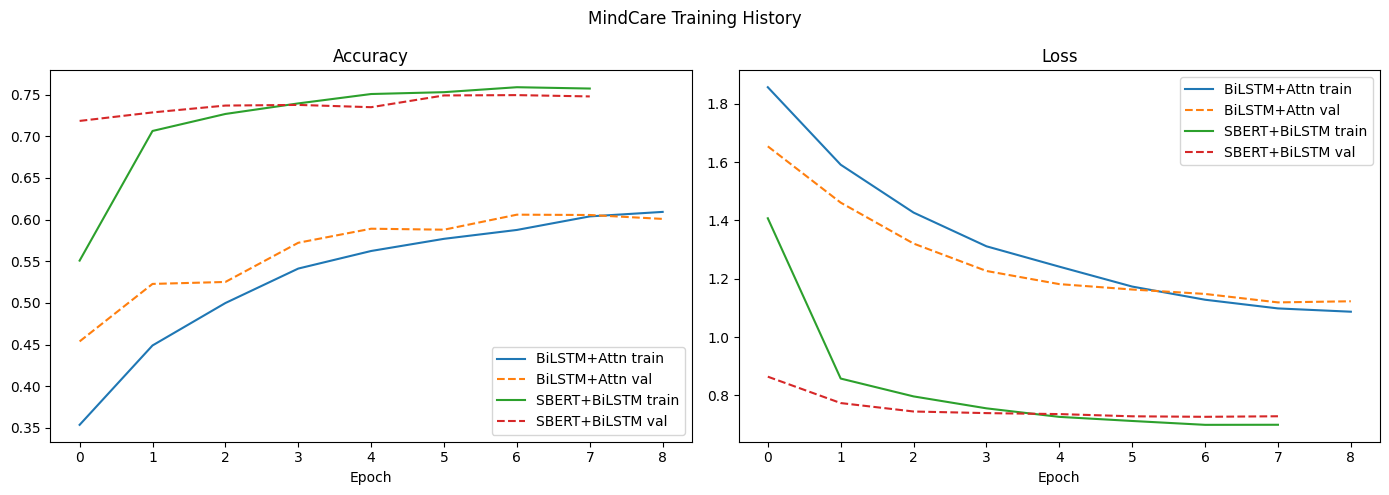

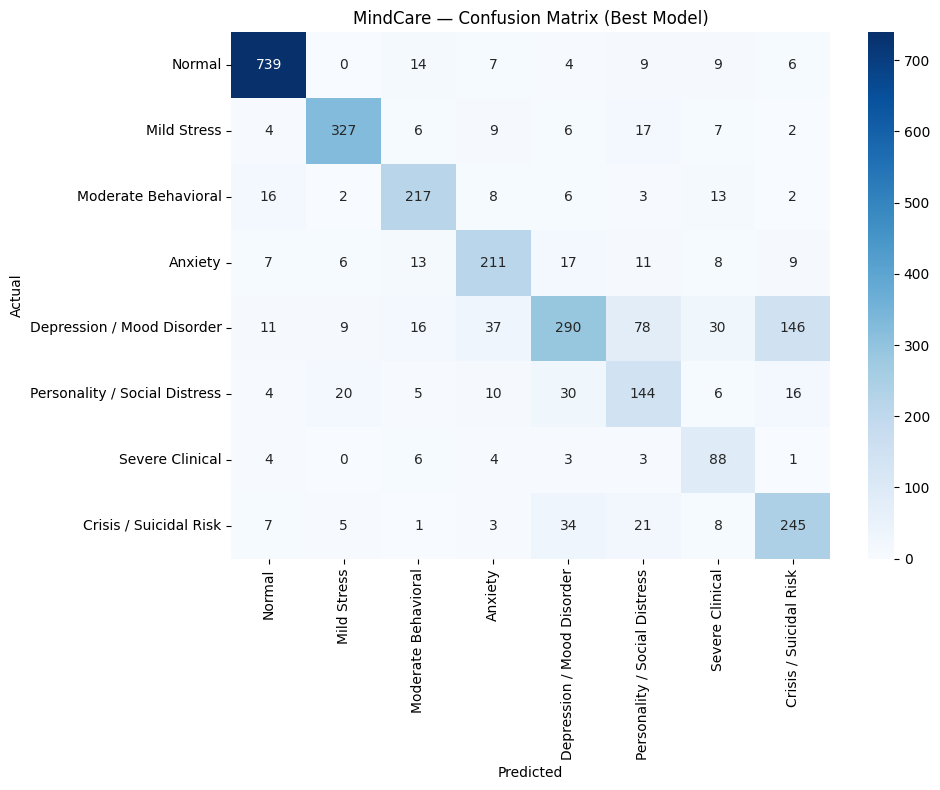

In [ ]:
results = pd.DataFrame([
    {'Model': 'SBERT + Logistic Regression', 'Accuracy': lr_acc,      'F1 (weighted)': lr_f1},
    {'Model': 'LSTM',                        'Accuracy': lstm_acc,    'F1 (weighted)': lstm_f1},
    {'Model': 'BiLSTM + Attention',          'Accuracy': bilstm_acc,  'F1 (weighted)': bilstm_f1},
    {'Model': 'SBERT + BiLSTM Ensemble',     'Accuracy': ens_acc,     'F1 (weighted)': ens_f1},
]).sort_values('Accuracy', ascending=False)

print('\n=== MindCare Model Comparison ===')
print(results.to_string(index=False, float_format='{:.4f}'.format))

# Training history plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in [('BiLSTM+Attn', bilstm_history), ('SBERT+BiLSTM', ensemble_history)]:
    axes[0].plot(hist['train_acc'], label=f'{name} train')
    axes[0].plot(hist['val_acc'],   linestyle='--', label=f'{name} val')
    axes[1].plot(hist['train_loss'],label=f'{name} train')
    axes[1].plot(hist['val_loss'],  linestyle='--', label=f'{name} val')

for ax, title in zip(axes, ['Accuracy', 'Loss']):
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()

plt.suptitle('MindCare Training History')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_history.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(ens_labels, ens_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('MindCare — Confusion Matrix (Best Model)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150)
plt.show()

## 8. Explainability — SHAP & LIME

In [ ]:
# ─── LIME ─────────────────────────────────────────────────────────────────────
lime_explainer = lime.lime_text.LimeTextExplainer(
    class_names=[LEVEL_NAMES.get(i, str(i)) for i in range(NUM_CLASSES)]
)

def lr_predict_proba(texts):
    if isinstance(texts, str):
        texts = [texts]
    embs = SBERT.encode(texts, show_progress_bar=False)
    return lr_model.predict_proba(embs)

sample_text  = "I feel so hopeless and I don't want to go on anymore"
sample_label = LEVEL_NAMES.get(7, '7')

print(f'Sample: "{sample_text}"')

lime_exp = lime_explainer.explain_instance(
    sample_text, lr_predict_proba, num_features=10, num_samples=300
)

print('\nLIME Top Features:')
for feat, weight in lime_exp.as_list():
    print(f'  {feat:25s}: {weight:+.4f}')

lime_exp.save_to_file(f'{SAVE_DIR}/lime_explanation.html')
print('LIME HTML saved.')

Sample: "I feel so hopeless and I don't want to go on anymore"

LIME Top Features:
  hopeless                 : -0.0258
  on                       : +0.0151
  I                        : -0.0111
  anymore                  : -0.0082
  go                       : +0.0073
  to                       : -0.0063
  want                     : +0.0063
  so                       : -0.0051
  don                      : -0.0034
  and                      : +0.0015
LIME HTML saved.


In [ ]:
# ─── SHAP (small subset for speed) ───────────────────────────────────────────
bg_idx   = np.random.choice(len(train_emb), size=100, replace=False)
bg_embs  = np.array(train_emb[bg_idx])
test_sub = np.array(test_emb[:5])

shap_explainer = shap.KernelExplainer(lr_model.predict_proba, bg_embs)
shap_values    = shap_explainer.shap_values(test_sub, nsamples=100)

print(f'SHAP computed for 5 samples | {len(shap_values)} classes')

100%|██████████| 5/5 [00:02<00:00,  2.09it/s]

SHAP computed for 5 samples | 5 classes


## 9. Save All Artifacts


Final Model Ranking:
                      Model  Accuracy  F1 (weighted)
SBERT + Logistic Regression    0.7613         0.7553
    SBERT + BiLSTM Ensemble    0.7537         0.7516
         BiLSTM + Attention    0.6187         0.6034
                       LSTM    0.4453         0.4388

Best Model: SBERT + Logistic Regression (0.7613)


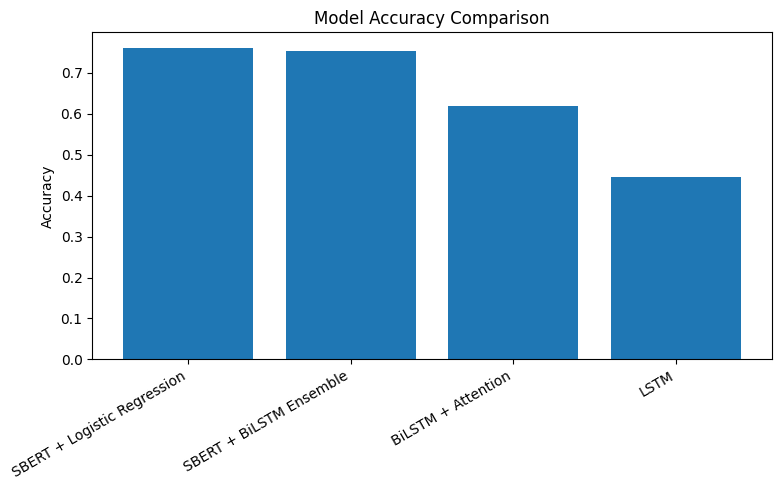


Saved Artifacts:
  bilstm_attention_best.pt                      19908.1 KB
  confusion_matrix.png                          112.1 KB
  lime_explanation.html                         1239.9 KB
  lstm_best.pt                                  11613.9 KB
  metadata.json                                 1.1 KB
  model_comparison.png                          47.9 KB
  sbert_bilstm_ensemble_best.pt                 20941.4 KB
  sbert_config.json                             0.0 KB
  sbert_lr_model.pkl                            76.0 KB
  training_history.png                          123.0 KB
  vocab.json                                    368.2 KB

Training complete. Models ready for API deployment.


In [ ]:
metadata = {
    'num_classes':     NUM_CLASSES,
    'class_names':     CLASS_NAMES,
    'level_names':     {str(k): v for k, v in LEVEL_NAMES.items()},
    'intervention_map':{str(k): v for k, v in INTERVENTION_MAP.items()},
    'max_len':         MAX_LEN,
    'max_vocab':       MAX_VOCAB,
    'sbert_model':     SBERT_MODEL_NAME,   # FIX: was hardcoded 'all-mpnet-base-v2'
    'sample_size':     SAMPLE_SIZE,
    'model_accuracies': {
        'sbert_lr':    round(lr_acc,      4),
        'lstm':        round(lstm_acc,    4),
        'bilstm_attn': round(bilstm_acc,  4),
        'sbert_bilstm':round(ens_acc,     4),
    }
}

with open(f'{SAVE_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

results_sorted = results.sort_values('Accuracy', ascending=False)
best_model = results_sorted.iloc[0]

print('\nFinal Model Ranking:')
print(results_sorted.to_string(index=False, float_format='{:.4f}'.format))
print(f"\nBest Model: {best_model['Model']} ({best_model['Accuracy']:.4f})")

plt.figure(figsize=(8, 5))
plt.bar(results_sorted['Model'], results_sorted['Accuracy'])
plt.xticks(rotation=30, ha='right')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/model_comparison.png', dpi=150)
plt.show()

print('\nSaved Artifacts:')
for fn in sorted(os.listdir(SAVE_DIR)):
    path = f'{SAVE_DIR}/{fn}'
    size = os.path.getsize(path)
    print(f'  {fn:45s} {size/1024:.1f} KB')

print('\nTraining complete. Models ready for API deployment.')